In [1]:
import pandas as pd
import numpy as np


In [2]:
full_df = pd.read_parquet('full_df.parquet')

In [3]:
full_df['hora'] = full_df['TW'].dt.hour
full_df['dia'] = full_df['TW'].dt.day_name()
full_df['mes'] = full_df['TW'].dt.month


In [4]:
dia_dummies = pd.get_dummies(full_df['dia'], prefix='dia', drop_first=True, dtype=int)

In [5]:
full_df = pd.concat([full_df, dia_dummies], axis=1)

In [6]:
full_df.head()

,TW,BARRIO,temperature,dewPoint,cloudCover,visibility,es_accidente,imputed_icon,imputed_precipIntensity,hora,dia,mes,dia_Monday,dia_Saturday,dia_Sunday,dia_Thursday,dia_Tuesday,dia_Wednesday
0,2017-01-01 00:00:00,aguasfrias,16.43,14.0,0.44,6.004,0.0,partly-cloudy-night,0.0,0,Sunday,1,0,0,1,0,0,0
1,2017-01-01 01:00:00,aguasfrias,16.43,14.0,0.44,6.004,0.0,partly-cloudy-night,0.0,1,Sunday,1,0,0,1,0,0,0
2,2017-01-01 02:00:00,aguasfrias,15.43,13.0,0.44,2.997,0.0,fog,0.0,2,Sunday,1,0,0,1,0,0,0
3,2017-01-01 03:00:00,aguasfrias,15.43,13.0,0.44,0.199,0.0,fog,0.0,3,Sunday,1,0,0,1,0,0,0
4,2017-01-01 04:00:00,aguasfrias,15.43,13.0,1.00,0.099,0.0,fog,0.0,4,Sunday,1,0,0,1,0,0,0


In [7]:
full_df.drop(columns=['dia'], inplace=True)

In [8]:

full_df['mes_sin'] = np.sin(2 * np.pi * full_df['mes'] / 12)
full_df['mes_cos'] = np.cos(2 * np.pi * full_df['mes'] / 12)

# opcional: si también quieres hacer cíclica la hora
full_df['hora_sin'] = np.sin(2 * np.pi * full_df['hora'] / 24)
full_df['hora_cos'] = np.cos(2 * np.pi * full_df['hora'] / 24)

full_df.drop(columns=['mes', 'hora'], inplace=True)


In [9]:
full_df.drop(columns=['TW','imputed_icon'], inplace=True)

In [10]:
full_df = pd.concat([full_df, pd.get_dummies(full_df['BARRIO'], prefix='barrio').astype(int)], axis=1).drop(columns=['BARRIO'])

In [11]:
full_df.head()

,temperature,dewPoint,cloudCover,visibility,es_accidente,imputed_precipIntensity,dia_Monday,dia_Saturday,dia_Sunday,dia_Thursday,...,barrio_villaflora,barrio_villaguadalupe,barrio_villahermosa,barrio_villaliliam,barrio_villalilliam,barrio_villaniza,barrio_villanueva,barrio_villatina,barrio_villaturbay,barrio_yolombo
0,16.43,14.0,0.44,6.004,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,16.43,14.0,0.44,6.004,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,15.43,13.0,0.44,2.997,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,15.43,13.0,0.44,0.199,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,15.43,13.0,1.00,0.099,0.0,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# del full_df['BARRIO'] 

In [13]:
full_df['es_accidente'].value_counts()

es_accidente
0.0    7775257
1.0     120340
Name: count, dtype: int64

In [14]:
X = full_df.drop(columns=['es_accidente'])
y = full_df['es_accidente']

In [15]:
from imblearn.under_sampling import RandomUnderSampler


# 2. Configurar el muestreador
# 'sampling_strategy="auto"' equilibra las clases al 50/50 automáticamente
rus = RandomUnderSampler(sampling_strategy=0.20, random_state=42)

# 3. Aplicar el submuestreo
X_resampled, y_resampled = rus.fit_resample(X, y)


In [16]:
y_resampled.value_counts()

es_accidente
0.0    601700
1.0    120340
Name: count, dtype: int64

In [17]:
X_resampled.filter(like='barrio_').melt().groupby('variable')['value'].sum().sort_values(ascending=False)

variable
barrio_lacandelaria                        4515
barrio_campoamor                           4385
barrio_caribe                              4161
barrio_perpetuosocorro                     4125
barrio_barriocolon                         4023
                                           ... 
barrio_suburbanochacaltaya                  710
barrio_palmitassectorcentral                666
barrio_corregimientodesanantoniodeprado     664
barrio_sanjavier                            660
barrio_manrique                             615
Name: value, Length: 309, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_resampled
)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"Balance train - Accidentes: {y_train.sum()} | Sin accidentes: {(y_train==0).sum()}")
print(f"Balance test - Accidentes: {y_test.sum()} | Sin accidentes: {(y_test==0).sum()}")


Conjunto de entrenamiento: (577632, 324)
Conjunto de prueba: (144408, 324)
Balance train - Accidentes: 96272.0 | Sin accidentes: 481360
Balance test - Accidentes: 24068.0 | Sin accidentes: 120340


In [ ]:
# 3. Entrenar múltiples clasificadores

# Modelo 1: Regresión Logística
print("=" * 50)
print("Entrenando Regresión Logística...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"ROC-AUC: {auc_lr:.4f}")

# Modelo 2: Random Forest
print("\n" + "=" * 50)
print("Entrenando Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC-AUC: {auc_rf:.4f}")

# Modelo 3: Gradient Boosting
print("\n" + "=" * 50)
print("Entrenando Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]
auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
print(f"ROC-AUC: {auc_gb:.4f}")


Entrenando Regresión Logística...


/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encou

ROC-AUC: 0.8059

Entrenando Random Forest...
ROC-AUC: 0.7909

Entrenando Gradient Boosting...


In [ ]:
# 4. Comparar modelos y mostrar solo el mejor según ROC-AUC

models = {
    'Logistic Regression': {'model': lr, 'pred': y_pred_lr, 'proba': y_pred_proba_lr, 'auc': auc_lr},
    'Random Forest': {'model': rf, 'pred': y_pred_rf, 'proba': y_pred_proba_rf, 'auc': auc_rf},
    'Gradient Boosting': {'model': gb, 'pred': y_pred_gb, 'proba': y_pred_proba_gb, 'auc': auc_gb}
}

best_model_name = max(models, key=lambda x: models[x]['auc'])
best_model = models[best_model_name]['model']
best_predictions = models[best_model_name]['pred']

cm = confusion_matrix(y_test, best_predictions)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, best_predictions)
precision = precision_score(y_test, best_predictions)
recall = recall_score(y_test, best_predictions)
f1 = f1_score(y_test, best_predictions)
auc = models[best_model_name]['auc']

print("\n" + "=" * 50)
print(f"MEJOR MODELO: {best_model_name}")
print(f"ROC-AUC: {auc:.4f}")
print("\nMatriz de confusión:")
print(cm)
print("\nMétricas asociadas:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("=" * 50)

NameError: name 'lr' is not defined

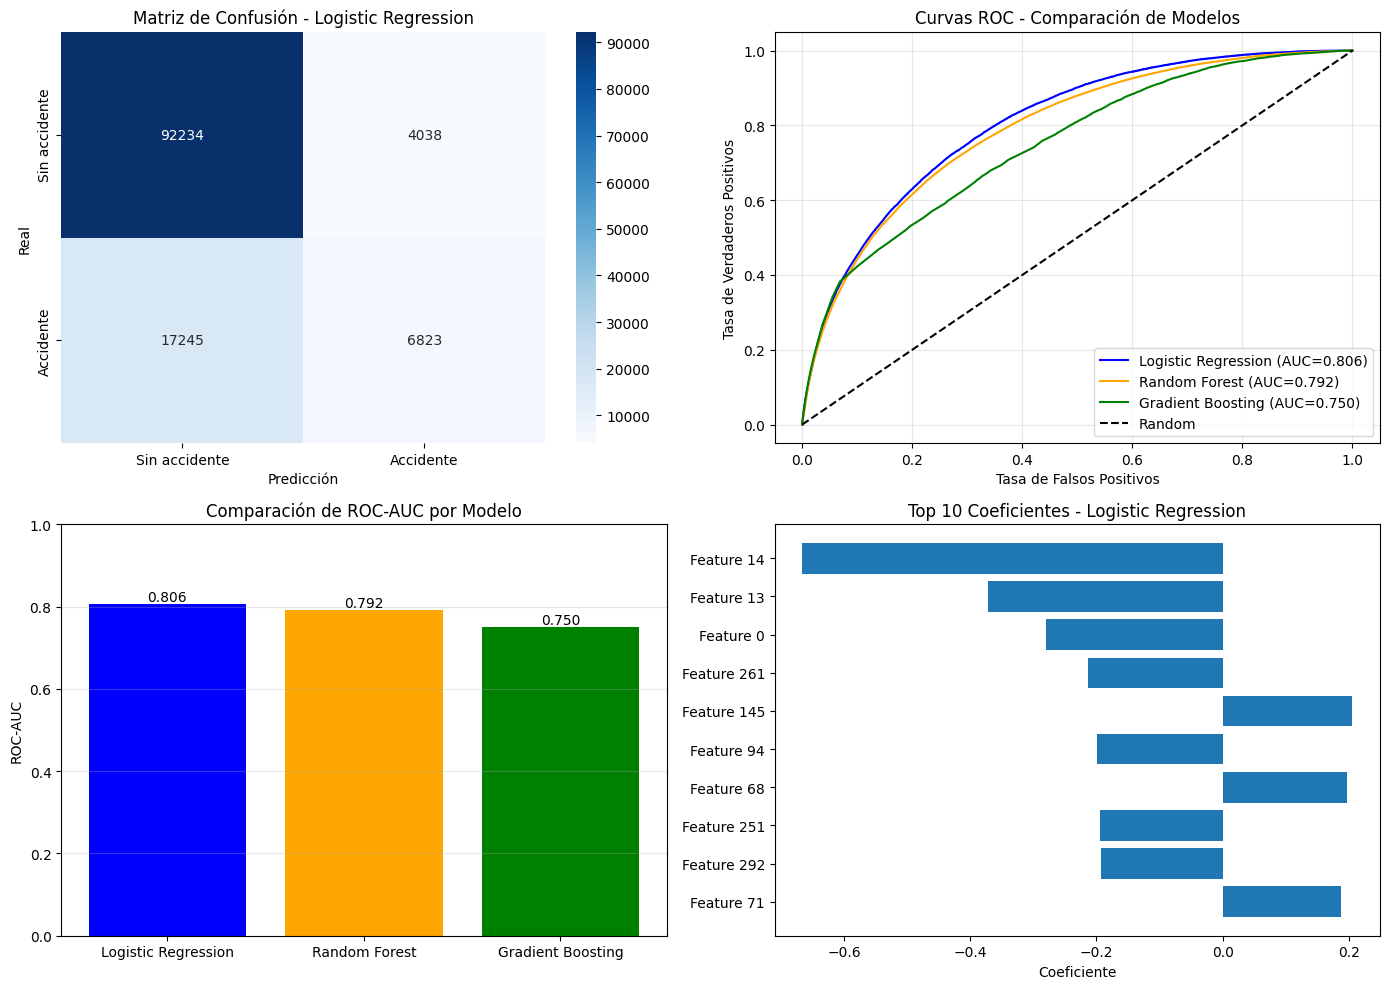

In [ ]:
# 5. Visualizar resultados

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Matriz de confusión del mejor modelo
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Sin accidente', 'Accidente'],
            yticklabels=['Sin accidente', 'Accidente'])
axes[0, 0].set_title(f'Matriz de Confusión - {best_model_name}')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_xlabel('Predicción')

# 2. Comparación ROC-AUC de todos los modelos
colors = ['blue', 'orange', 'green']
for (name, model_dict), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, model_dict['proba'])
    axes[0, 1].plot(fpr, tpr, label=f"{name} (AUC={model_dict['auc']:.3f})", color=color)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos')
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 1].set_title('Curvas ROC - Comparación de Modelos')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. AUC comparison
auc_values = [models[name]['auc'] for name in models.keys()]
bars = axes[1, 0].bar(models.keys(), auc_values, color=colors)
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('Comparación de ROC-AUC por Modelo')
axes[1, 0].set_ylim([0, 1])
for bar, auc in zip(bars, auc_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{auc:.3f}', ha='center', va='bottom')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Importancia de features del mejor modelo (si es RandomForest o GradientBoosting)
if best_model_name != 'Logistic Regression':
    feature_importance = models[best_model_name]['model'].feature_importances_
    top_features_idx = np.argsort(feature_importance)[-10:]
    axes[1, 1].barh(range(len(top_features_idx)), feature_importance[top_features_idx])
    axes[1, 1].set_yticks(range(len(top_features_idx)))
    axes[1, 1].set_yticklabels([f'Feature {i}' for i in top_features_idx])
    axes[1, 1].set_xlabel('Importancia')
    axes[1, 1].set_title(f'Top 10 Features - {best_model_name}')
else:
    coefficients = models[best_model_name]['model'].coef_[0]
    top_features_idx = np.argsort(np.abs(coefficients))[-10:]
    axes[1, 1].barh(range(len(top_features_idx)), coefficients[top_features_idx])
    axes[1, 1].set_yticks(range(len(top_features_idx)))
    axes[1, 1].set_yticklabels([f'Feature {i}' for i in top_features_idx])
    axes[1, 1].set_xlabel('Coeficiente')
    axes[1, 1].set_title(f'Top 10 Coeficientes - {best_model_name}')

plt.tight_layout()
plt.show()


In [ ]:
# 6. Guardar el modelo y scaler para predicciones futuras
import joblib

# Guardar modelo y scaler
joblib.dump(models[best_model_name]['model'], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"\n✓ Modelo {best_model_name} guardado como 'best_model.pkl'")
print(f"✓ Scaler guardado como 'scaler.pkl'")
print(f"\nPara hacer predicciones nuevas:")
print(f"  1. Cargar: model = joblib.load('best_model.pkl')")
print(f"  2. Cargar: scaler = joblib.load('scaler.pkl')")
print(f"  3. Escalar nuevos datos: X_nuevo_scaled = scaler.transform(X_nuevo)")
print(f"  4. Predecir: y_nuevo = model.predict(X_nuevo_scaled)")



✓ Modelo Logistic Regression guardado como 'best_model.pkl'
✓ Scaler guardado como 'scaler.pkl'

Para hacer predicciones nuevas:
  1. Cargar: model = joblib.load('best_model.pkl')
  2. Cargar: scaler = joblib.load('scaler.pkl')
  3. Escalar nuevos datos: X_nuevo_scaled = scaler.transform(X_nuevo)
  4. Predecir: y_nuevo = model.predict(X_nuevo_scaled)


: 